In [1]:
# ============================================================
# AI-Assisted Structure-Based Drug Discovery Mini Pipeline
# Target: E. coli DHFR
#
# Overall Workflow:
# 1. Download protein sequence
# 2. Run AlphaFold/ColabFold separately
# 3. Load predicted structure
# 4. Check model confidence
# 5. Visualize structure
# 6. Prepare protein for docking
# 7. Prepare ligand
# 8. Run docking
# 9. Analyze docking scores
# 10. Visualize protein-ligand pose
# 11. Use OpenAI API to generate scientific interpretation
# ============================================================

In [2]:
# ============================================================
# STEP 1: Setup Project Folder in Google Drive
#
# Input:
# - Google Drive access
#
# Output:
# - Clean project folder structure saved permanently in Drive
# ============================================================

from pathlib import Path
from datetime import datetime
import pandas as pd
from IPython.display import display, Markdown
from google.colab import drive

drive.mount("/content/drive")

PROJECT_NAME = "ai_structure_drug_discovery_dhfr"
BASE_DIR = Path("/content/drive/MyDrive") / PROJECT_NAME

DIRS = {
    "raw_data": BASE_DIR / "data" / "raw",
    "processed_data": BASE_DIR / "data" / "processed",
    "ligands": BASE_DIR / "data" / "ligands",
    "colabfold_outputs": BASE_DIR / "outputs" / "colabfold",
    "docking_outputs": BASE_DIR / "outputs" / "docking",
    "ai_outputs": BASE_DIR / "outputs" / "ai_summaries",
    "figures": BASE_DIR / "figures"
}

for folder in DIRS.values():
    folder.mkdir(parents=True, exist_ok=True)

display(Markdown("## Project folders created"))
display(pd.DataFrame(
    [{"Folder Type": k, "Path": str(v)} for k, v in DIRS.items()]
))

Mounted at /content/drive


## Project folders created

,Folder Type,Path
0,raw_data,/content/drive/MyDrive/ai_structure_drug_disco...
1,processed_data,/content/drive/MyDrive/ai_structure_drug_disco...
2,ligands,/content/drive/MyDrive/ai_structure_drug_disco...
3,colabfold_outputs,/content/drive/MyDrive/ai_structure_drug_disco...
4,docking_outputs,/content/drive/MyDrive/ai_structure_drug_disco...
5,ai_outputs,/content/drive/MyDrive/ai_structure_drug_disco...
6,figures,/content/drive/MyDrive/ai_structure_drug_disco...


In [3]:
# ============================================================
# STEP 3: Run AlphaFold2 / ColabFold Externally
#
# Input:
# - Clean DHFR amino acid sequence from Step 2
#
# Output:
# - Predicted protein structure file: .pdb
#
# IMPORTANT:
# Run ColabFold using the official notebook:
# https://colab.research.google.com/github/sokrypton/ColabFold/blob/main/AlphaFold2.ipynb
#
# Use:
# jobname = DHFR_ECOLI
#
# query_sequence =
# MISLIAALAVDRVIGMENAMPWNLPADLAWFKRNTLNKPVIMGRHTWESIGRPLPGRKNIILSSQPGTDDRVTWVKSVDEAIAACGDVPEIMVIGGGRVYEQFLPKAQKLYLTHIDAEVEGDTHFPDYEPDDWESVFSEFHDADAQNSHSYCFEILERR
#
# Settings:
# - num_models: 1 or 5
# - num_recycles: 1 or 3
# - template_mode: none
# - amber: off
#
# After ColabFold finishes:
# Save the rank_001 .pdb file into:
# /content/drive/MyDrive/ai_structure_drug_discovery_dhfr/outputs/colabfold/
#
# Then continue from Step 4 below.
# ============================================================

In [4]:
# ============================================================
# STEP 4: Load Predicted AlphaFold / ColabFold Structure
#
# Input:
# - rank_001 .pdb file saved in outputs/colabfold/
#
# Output:
# - Selected best_pdb file for downstream analysis
# ============================================================

COLABFOLD_DIR = DIRS["colabfold_outputs"]

pdb_files = sorted(COLABFOLD_DIR.glob("*.pdb"))

if len(pdb_files) == 0:
    raise FileNotFoundError(
        "No PDB file found. Please save the ColabFold rank_001 PDB file "
        "inside outputs/colabfold/ before continuing."
    )

rank_001_files = [f for f in pdb_files if "rank_001" in f.name]

best_pdb = rank_001_files[0] if rank_001_files else pdb_files[0]

display(Markdown("## Selected AlphaFold / ColabFold structure"))
display(Markdown(f"Using file: `{best_pdb}`"))

with open(best_pdb, "r") as f:
    print("".join(f.readlines()[:20]))

## Selected AlphaFold / ColabFold structure

Using file: `/content/drive/MyDrive/ai_structure_drug_discovery_dhfr/outputs/colabfold/test_e559b_unrelaxed_rank_001_alphafold2_ptm_model_1_seed_000.pdb`

MODEL     1                                                                     
ATOM      1  N   MET A   1      -5.566  11.875   7.520  1.00 95.94           N  
ATOM      2  CA  MET A   1      -5.215  11.797   6.105  1.00 95.94           C  
ATOM      3  C   MET A   1      -5.168  10.352   5.633  1.00 95.94           C  
ATOM      4  CB  MET A   1      -3.867  12.477   5.852  1.00 95.94           C  
ATOM      5  O   MET A   1      -4.641   9.484   6.328  1.00 95.94           O  
ATOM      6  CG  MET A   1      -3.398  12.383   4.406  1.00 95.94           C  
ATOM      7  SD  MET A   1      -1.672  12.969   4.191  1.00 95.94           S  
ATOM      8  CE  MET A   1      -1.869  14.719   4.633  1.00 95.94           C  
ATOM      9  N   ILE A   2      -5.660  10.078   4.375  1.00 98.25           N  
ATOM     10  CA  ILE A   2      -5.664   8.742   3.803  1.00 98.25           C  
ATOM     11  C   ILE A   2      -4.629   8.648   2.684  1.00 98.25           C  
ATOM     12  CB  ILE A   2  

## AlphaFold confidence summary

,Number of residues,Mean pLDDT,Minimum pLDDT,Maximum pLDDT,Residues above 90,Residues between 70 and 90,Residues below 70
0,159,95.49,77.25,98.75,146,13,0


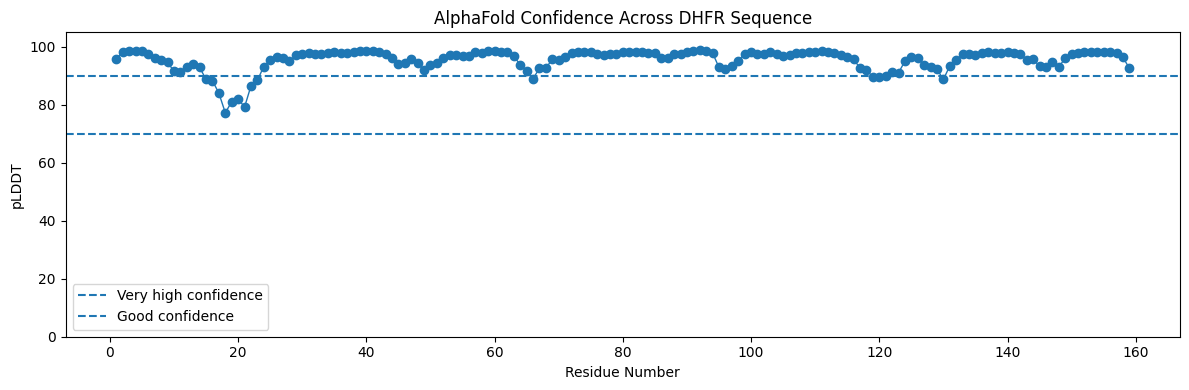

In [6]:
# ============================================================
# STEP 5: Extract AlphaFold Confidence Scores
#
# Input:
# - Predicted PDB file
#
# Output:
# - Residue-level pLDDT confidence table
# - Confidence plot
#
# Note:
# AlphaFold stores pLDDT confidence scores in the B-factor column of the PDB.
# ============================================================

import matplotlib.pyplot as plt
records = []

with open(best_pdb, "r") as f:
    for line in f:
        if line.startswith("ATOM"):
            atom_name = line[12:16].strip()

            if atom_name == "CA":
                residue_name = line[17:20].strip()
                residue_number = int(line[22:26].strip())
                plddt = float(line[60:66].strip())

                records.append({
                    "Residue_Number": residue_number,
                    "Residue": residue_name,
                    "pLDDT": plddt
                })

plddt_df = pd.DataFrame(records)

confidence_summary = {
    "Number of residues": len(plddt_df),
    "Mean pLDDT": round(plddt_df["pLDDT"].mean(), 2),
    "Minimum pLDDT": round(plddt_df["pLDDT"].min(), 2),
    "Maximum pLDDT": round(plddt_df["pLDDT"].max(), 2),
    "Residues above 90": int((plddt_df["pLDDT"] >= 90).sum()),
    "Residues between 70 and 90": int(((plddt_df["pLDDT"] >= 70) & (plddt_df["pLDDT"] < 90)).sum()),
    "Residues below 70": int((plddt_df["pLDDT"] < 70).sum())
}

display(Markdown("## AlphaFold confidence summary"))
display(pd.DataFrame([confidence_summary]))

confidence_path = DIRS["colabfold_outputs"] / "dhfr_plddt_scores.csv"
plddt_df.to_csv(confidence_path, index=False)

plt.figure(figsize=(12, 4))
plt.plot(plddt_df["Residue_Number"], plddt_df["pLDDT"], marker="o", linewidth=1)
plt.axhline(90, linestyle="--", label="Very high confidence")
plt.axhline(70, linestyle="--", label="Good confidence")
plt.title("AlphaFold Confidence Across DHFR Sequence")
plt.xlabel("Residue Number")
plt.ylabel("pLDDT")
plt.ylim(0, 105)
plt.legend()
plt.tight_layout()

confidence_plot_path = DIRS["figures"] / "plddt_confidence_plot.png"
plt.savefig(confidence_plot_path, dpi=300)
plt.show()

In [7]:
# ============================================================
# STEP 6: Visualize Protein Structure in 3D
#
# Input:
# - Predicted PDB file
#
# Output:
# - Interactive 3D protein structure
# ============================================================

!pip -q install py3Dmol

import py3Dmol

with open(best_pdb, "r") as f:
    pdb_data = f.read()

display(Markdown("## 3D protein structure"))

view = py3Dmol.view(width=850, height=650)
view.addModel(pdb_data, "pdb")
view.setStyle({"cartoon": {"color": "spectrum"}})
view.zoomTo()
view.show()

## 3D protein structure

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [8]:
# ============================================================
# STEP 7: Visualize Protein Colored by Confidence
#
# Input:
# - Predicted PDB file
#
# Output:
# - Interactive 3D structure colored by pLDDT
#
# Interpretation:
# - Blue/green = high confidence
# - Yellow/red = lower confidence
# ============================================================

display(Markdown("## 3D protein structure colored by AlphaFold confidence"))

view = py3Dmol.view(width=850, height=650)
view.addModel(pdb_data, "pdb")

view.setStyle({
    "cartoon": {
        "colorscheme": {
            "prop": "b",
            "gradient": "roygb",
            "min": 0,
            "max": 100
        }
    }
})

view.zoomTo()
view.show()

## 3D protein structure colored by AlphaFold confidence

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [9]:
# ============================================================
# STEP 8: Prepare Protein for Docking
#
# Input:
# - Predicted protein PDB file
#
# Output:
# - Clean receptor PDBQT file for AutoDock Vina
#
# Why:
# Docking tools need a chemically prepared receptor format.
# ============================================================

!apt-get -qq install -y openbabel > /dev/null

import subprocess

raw_receptor_pdbqt = DIRS["docking_outputs"] / "dhfr_receptor_raw.pdbqt"
clean_receptor = DIRS["docking_outputs"] / "dhfr_receptor_clean.pdbqt"

cmd = [
    "obabel",
    "-ipdb", str(best_pdb),
    "-opdbqt",
    "-O", str(raw_receptor_pdbqt),
    "-h"
]

result = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
print(result.stdout)

if not raw_receptor_pdbqt.exists():
    raise RuntimeError("Protein PDBQT conversion failed.")

# Clean receptor:
# Vina expects receptor files to contain protein atom records only.
# We remove ligand-style tags such as ROOT and BRANCH.

kept_lines = []

with open(raw_receptor_pdbqt, "r") as f:
    for line in f:
        if line.startswith("ATOM") or line.startswith("HETATM"):
            kept_lines.append(line)

with open(clean_receptor, "w") as f:
    f.writelines(kept_lines)
    f.write("END\n")

display(Markdown("## Protein prepared for docking"))
display(Markdown(f"Clean receptor saved to: `{clean_receptor}`"))

print("Number of receptor atom lines:", len(kept_lines))

*** Open Babel Warning  in PerceiveBondOrders
  Failed to kekulize aromatic bonds in OBMol::PerceiveBondOrders (title is /content/drive/MyDrive/ai_structure_drug_discovery_dhfr/outputs/colabfold/test_e559b_unrelaxed_rank_001_alphafold2_ptm_model_1_seed_000.pdb)

1 molecule converted



## Protein prepared for docking

Clean receptor saved to: `/content/drive/MyDrive/ai_structure_drug_discovery_dhfr/outputs/docking/dhfr_receptor_clean.pdbqt`

Number of receptor atom lines: 1533


In [10]:
# ============================================================
# STEP 9: Download and Prepare Ligand
#
# Input:
# - PubChem compound ID
#
# Output:
# - Ligand SDF file
# - Ligand PDBQT file for docking
#
# Note:
# CID 1983 is used here as a demo ligand.
# You can replace it later with another compound.
# ============================================================

import requests

ligand_sdf = DIRS["ligands"] / "ligand.sdf"
ligand_pdbqt = DIRS["ligands"] / "ligand.pdbqt"

pubchem_cid = "1983"
ligand_url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/CID/{pubchem_cid}/SDF"

response = requests.get(ligand_url, timeout=30)

if response.status_code != 200:
    raise RuntimeError("Could not download ligand from PubChem.")

with open(ligand_sdf, "w") as f:
    f.write(response.text)

cmd = [
    "obabel",
    "-isdf", str(ligand_sdf),
    "-opdbqt",
    "-O", str(ligand_pdbqt),
    "--gen3d",
    "-h"
]

result = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
print(result.stdout)

if not ligand_pdbqt.exists():
    raise RuntimeError("Ligand PDBQT conversion failed.")

display(Markdown("## Ligand prepared for docking"))
display(Markdown(f"Ligand PDBQT saved to: `{ligand_pdbqt}`"))

1 molecule converted



## Ligand prepared for docking

Ligand PDBQT saved to: `/content/drive/MyDrive/ai_structure_drug_discovery_dhfr/data/ligands/ligand.pdbqt`

In [11]:
# ============================================================
# STEP 10: Run Molecular Docking with AutoDock Vina
#
# Input:
# - Clean receptor PDBQT
# - Ligand PDBQT
#
# Output:
# - Docked ligand pose
# - Docking score table
#
# Interpretation:
# More negative score usually suggests stronger predicted binding,
# but docking scores are approximate and not experimental proof.
# ============================================================

!apt-get -qq install -y autodock-vina > /dev/null

import numpy as np
import re

coords = []

with open(clean_receptor, "r") as f:
    for line in f:
        if line.startswith("ATOM") or line.startswith("HETATM"):
            x = float(line[30:38])
            y = float(line[38:46])
            z = float(line[46:54])
            coords.append([x, y, z])

coords = np.array(coords)
center = coords.mean(axis=0)

display(Markdown("## Docking search box center"))
display(pd.DataFrame([{
    "center_x": center[0],
    "center_y": center[1],
    "center_z": center[2],
    "size_x": 24,
    "size_y": 24,
    "size_z": 24
}]))

docked_ligand = DIRS["docking_outputs"] / "docked.pdbqt"
vina_log = DIRS["docking_outputs"] / "vina_output_log.txt"

cmd = [
    "vina",
    "--receptor", str(clean_receptor),
    "--ligand", str(ligand_pdbqt),
    "--center_x", str(center[0]),
    "--center_y", str(center[1]),
    "--center_z", str(center[2]),
    "--size_x", "24",
    "--size_y", "24",
    "--size_z", "24",
    "--exhaustiveness", "8",
    "--num_modes", "5",
    "--out", str(docked_ligand)
]

result = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)

with open(vina_log, "w") as f:
    f.write(result.stdout)

print(result.stdout)

if result.returncode != 0:
    raise RuntimeError("Docking failed. Check Vina output above.")

score_rows = []

for line in result.stdout.splitlines():
    match = re.match(r"\s*(\d+)\s+(-?\d+\.\d+)\s+([\d\.]+)\s+([\d\.]+)", line)
    if match:
        score_rows.append({
            "Mode": int(match.group(1)),
            "Affinity_kcal_per_mol": float(match.group(2)),
            "RMSD_lb": float(match.group(3)),
            "RMSD_ub": float(match.group(4))
        })

scores_df = pd.DataFrame(score_rows)

scores_path = DIRS["docking_outputs"] / "vina_scores.csv"
scores_df.to_csv(scores_path, index=False)

display(Markdown("## Docking scores"))
display(scores_df)

best_score = scores_df["Affinity_kcal_per_mol"].min()

display(Markdown(f"## Best docking score: **{best_score} kcal/mol**"))

## Docking search box center

,center_x,center_y,center_z,size_x,size_y,size_z
0,-0.43742,-0.487769,-0.801045,24,24,24


AutoDock Vina v1.2.3
#################################################################
# If you used AutoDock Vina in your work, please cite:          #
#                                                               #
# J. Eberhardt, D. Santos-Martins, A. F. Tillack, and S. Forli  #
# AutoDock Vina 1.2.0: New Docking Methods, Expanded Force      #
# Field, and Python Bindings, J. Chem. Inf. Model. (2021)       #
# DOI 10.1021/acs.jcim.1c00203                                  #
#                                                               #
# O. Trott, A. J. Olson,                                        #
# AutoDock Vina: improving the speed and accuracy of docking    #
# with a new scoring function, efficient optimization and       #
# multithreading, J. Comp. Chem. (2010)                         #
# DOI 10.1002/jcc.21334                                         #
#                                                               #
# Please see https://github.com/ccsb-scripps/AutoDock-V

## Docking scores

,Mode,Affinity_kcal_per_mol,RMSD_lb,RMSD_ub
0,1,-5.686,0.000,0.000
1,2,-5.676,1.961,5.167
2,3,-5.446,2.529,3.526
3,4,-5.297,2.298,5.204
4,5,-5.215,4.070,5.080


## Best docking score: **-5.686 kcal/mol**

In [12]:
# ============================================================
# STEP 11: Visualize Protein-Ligand Docking Pose
#
# Input:
# - Clean receptor PDBQT
# - Docked ligand PDBQT
#
# Output:
# - Interactive protein-ligand visualization
# ============================================================

protein_data = clean_receptor.read_text()
ligand_data = docked_ligand.read_text()

display(Markdown("## Protein-ligand docking pose"))

view = py3Dmol.view(width=850, height=650)

view.addModel(protein_data, "pdbqt")
view.setStyle(
    {"model": 0},
    {"cartoon": {"color": "lightblue"}}
)

view.addModel(ligand_data, "pdbqt")
view.setStyle(
    {"model": 1},
    {"stick": {"colorscheme": "greenCarbon", "radius": 0.25}}
)

view.addSurface(
    py3Dmol.VDW,
    {"opacity": 0.25, "color": "white"},
    {"model": 0}
)

view.zoomTo({"model": 1})
view.show()

## Protein-ligand docking pose

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [13]:
# ============================================================
# STEP 12: Identify Protein Residues Near Docked Ligand
#
# Input:
# - Clean receptor
# - Docked ligand
#
# Output:
# - Residues within 4.5 Å of ligand
#
# Why:
# These residues form the putative interaction zone.
# ============================================================

lig_coords = []

with open(docked_ligand, "r") as f:
    for line in f:
        if line.startswith("ATOM") or line.startswith("HETATM"):
            x = float(line[30:38])
            y = float(line[38:46])
            z = float(line[46:54])
            lig_coords.append([x, y, z])

lig_coords = np.array(lig_coords)

protein_atoms = []

with open(clean_receptor, "r") as f:
    for line in f:
        if line.startswith("ATOM") or line.startswith("HETATM"):
            atom_name = line[12:16].strip()
            res_name = line[17:20].strip()
            res_num = int(line[22:26].strip())
            x = float(line[30:38])
            y = float(line[38:46])
            z = float(line[46:54])

            protein_atoms.append({
                "Residue": res_name,
                "Residue_Number": res_num,
                "Atom": atom_name,
                "Coord": np.array([x, y, z])
            })

interaction_cutoff = 4.5
interacting_residues = set()

for atom in protein_atoms:
    for lig_atom in lig_coords:
        distance = np.linalg.norm(atom["Coord"] - lig_atom)

        if distance < interaction_cutoff:
            interacting_residues.add((atom["Residue"], atom["Residue_Number"]))
            break

interaction_df = pd.DataFrame(
    list(interacting_residues),
    columns=["Residue", "Residue_Number"]
).sort_values("Residue_Number")

interaction_path = DIRS["docking_outputs"] / "interacting_residues.csv"
interaction_df.to_csv(interaction_path, index=False)

display(Markdown("## Putative interacting residues within 4.5 Å"))
display(interaction_df)

## Putative interacting residues within 4.5 Å

,Residue,Residue_Number
1,ILE,5
3,ALA,6
16,ALA,7
2,ILE,14
10,GLY,15
6,ASN,18
17,ALA,19
5,MET,20
18,ASP,27
14,PHE,31


In [14]:
# ============================================================
# STEP 13: OpenAI API Scientific Interpretation
#
# Input:
# - AlphaFold confidence summary
# - Docking score
# - Interacting residues
#
# Output:
# - AI-assisted scientific interpretation report
#
# Important:
# The LLM helps write and explain results.
# It does not validate biological activity.
# ============================================================

!pip -q install openai

from openai import OpenAI
import os
import getpass

os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API key: ")

client = OpenAI()

system_message = """
You are an expert computational structural biology assistant.
You interpret AlphaFold/ColabFold and docking outputs cautiously.

Do not claim that the ligand is a validated drug.
Do not claim experimental binding.
Use careful language such as:
- computationally plausible
- exploratory
- hypothesis-generating
- requires experimental validation

Write in a polished GitHub portfolio style.
"""

user_message = f"""
Project: AI-assisted structure-based drug discovery mini-pipeline

Target:
- E. coli DHFR / folA
- Structure predicted using ColabFold / AlphaFold2-style workflow

AlphaFold confidence summary:
{confidence_summary}

Docking:
- Best AutoDock Vina score: {best_score} kcal/mol

Interacting residues within 4.5 Å:
{interaction_df.to_dict(orient="records")}

Please generate a structured scientific interpretation with:

1. Objective
2. Structural Model Quality
3. Docking Result Interpretation
4. Putative Interaction Zone
5. Scientific Limitations
6. Recommended Next Steps
7. GitHub-ready summary paragraph
"""

response = client.responses.create(
    model="gpt-4.1-mini",
    input=[
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_message}
    ]
)

ai_report = response.output_text

display(Markdown("## AI-Assisted Scientific Interpretation"))
display(Markdown(ai_report))

report_path = DIRS["ai_outputs"] / "ai_scientific_interpretation.md"

with open(report_path, "w") as f:
    f.write(ai_report)

display(Markdown(f"Report saved to: `{report_path}`"))

Enter your OpenAI API key: ··········


## AI-Assisted Scientific Interpretation

1. Objective  
The project aims to explore a mini-pipeline for AI-assisted structure-based drug discovery targeting E. coli dihydrofolate reductase (DHFR, folA). The approach involved predicting the 3D structure of E. coli DHFR using a ColabFold / AlphaFold2-style workflow, followed by molecular docking of a compound with AutoDock Vina to identify computationally plausible binding interactions.

2. Structural Model Quality  
The predicted DHFR structure contains 159 residues with a high overall confidence indicated by a mean pLDDT score of 95.49. The majority of residues (146 out of 159) have pLDDT values above 90, representing very high confidence in local structural accuracy. Only 13 residues fall within the medium confidence range (70–90), and none below 70, suggesting a reliable model suitable for downstream docking analyses.

3. Docking Result Interpretation  
The best docking score obtained from AutoDock Vina was −5.686 kcal/mol. While this score indicates a moderately favorable binding affinity, it should be regarded as an exploratory measure of ligand-target complementarity rather than a validated binding free energy. This interaction score supports prioritizing the compound for further computational and experimental investigation, recognizing the heuristics inherent to docking scoring functions.

4. Putative Interaction Zone  
The docked ligand is predicted to interact with multiple residues within a 4.5 Å radius, including hydrophobic residues (ILE5, ILE14, ILE94), polar and charged residues (ASN18, ASP27, ARG98), and aromatic residues (PHE31, TYR100, HIS45). Glycine-rich loops (GLY95-97) and threonine side chains (THR46, THR123) also appear involved, which may contribute to binding through flexible loop regions or hydrogen bonding. This interaction cluster likely represents the putative ligand-binding site, consistent with the canonical substrate binding region of DHFR.

5. Scientific Limitations  
- The AlphaFold2-derived structure is a prediction, and despite high confidence, may not capture dynamic conformations or alternate binding site states.  
- Docking scores are simplified approximations and do not account for entropic effects, solvation dynamics, or induced fit conformational changes.  
- Experimental validation is necessary to confirm binding affinity and functional inhibition.  
- The ligand identity and chemical nature were not discussed, and off-target effects or bioavailability cannot be inferred.  
- The analysis does not consider potential allosteric sites or competitive binding with endogenous substrates/cofactors.

6. Recommended Next Steps  
- Experimentally validate the predicted DHFR structure, e.g., via crystallography or NMR, if feasible.  
- Perform molecular dynamics simulations on the protein-ligand complex to evaluate stability and refine interaction details.  
- Expand docking studies including known DHFR inhibitors as positive controls to benchmark scoring and binding modes.  
- Carry out in vitro biochemical assays to empirically measure binding affinity and enzyme inhibition.  
- Investigate structure-activity relationships (SAR) by docking analogues to optimize binding affinity.  

7. GitHub-ready Summary Paragraph  
This project presents an AI-assisted structure-based drug discovery mini-pipeline targeting E. coli DHFR (folA). Using a ColabFold/AlphaFold2 prediction approach, we obtained a highly confident 3D model (mean pLDDT 95.49) suitable for ligand docking. AutoDock Vina docking of a candidate compound yielded a best score of −5.686 kcal/mol, with the ligand interacting at key residues within the canonical binding site, including hydrophobic, polar, and aromatic amino acids. These results provide a computationally plausible interaction hypothesis warranting further validation. Limitations of predictive modeling and docking scoring are noted, and recommended next steps include experimental verification and dynamic simulations to strengthen confidence in the proposed binding mode. This pipeline demonstrates a promising exploratory framework for rapid AI-driven hit identification in antibiotic target contexts.

Report saved to: `/content/drive/MyDrive/ai_structure_drug_discovery_dhfr/outputs/ai_summaries/ai_scientific_interpretation.md`